In [13]:
#import 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np


In [14]:
#load processed data 
df_particles=pd.read_csv('processed_data/cleaned_fine_particles_data.csv')
df_no2=pd.read_csv('processed_data/cleaned_nitrogen_dioxide_data.csv')
df_traffic=pd.read_csv('processed_data/cleaned_traffic_data.csv')

In [4]:
print("RAW TRAFFIC TYPE:", type(df_traffic['DateTime'].iloc[0]))
print("RAW PARTICLES TYPE:", type(df_particles['TimePeriod'].iloc[0]))

RAW TRAFFIC TYPE: <class 'str'>
RAW PARTICLES TYPE: <class 'str'>


In [15]:
#add text col of boro

# 1hot encoding cols 
cols = ['Borough_Manhattan', 'Borough_Brooklyn', 'Borough_Queens', 'Borough_Staten Island']

# add the text for the 4 defined (particles)
df_particles['Borough'] = df_particles[cols].idxmax(axis=1).str.replace('Borough_', '')

# add manhattan (particles)
df_particles.loc[df_particles[cols].sum(axis=1) == 0, 'Borough'] = 'Bronx'

#save
df_particles.to_csv('processed_data/cleaned_fine_particles_data.csv', index=False)

# add the text for the 4 defined (no2)
df_no2['Borough'] = df_no2[cols].idxmax(axis=1).str.replace('Borough_', '')

# add manhattan (no2)
df_no2.loc[df_no2[cols].sum(axis=1) == 0, 'Borough'] = 'Bronx'

#save 
df_no2.to_csv('processed_data/cleaned_nitrogen_dioxide_data.csv', index=False)

traffic_cols=['Boro_Manhattan', 'Boro_Brooklyn', 'Boro_Queens', 'Boro_Staten Island']

# add the text for the 4 defined (traffic)
df_traffic['Boro'] = df_traffic[traffic_cols].idxmax(axis=1).str.replace('Boro_', '')

# add manhattan (traffic)
df_traffic.loc[df_traffic[traffic_cols].sum(axis=1) == 0, 'Boro'] = 'Bronx'

#save 
df_traffic.to_csv('processed_data/cleaned_traffic_data.csv', index=False)

In [16]:
#sql stuff
import sqlite3
conn = sqlite3.connect('main.db')

#update the staten island col name + date
df_particles = df_particles.rename(columns={
    'Borough_Staten Island': 'Borough_Staten_Island', 
    'TimePeriod': 'Date'
})
df_no2 = df_no2.rename(columns={
    'Borough_Staten Island': 'Borough_Staten_Island',
    'TimePeriod': 'Date'
})
#update the names for traffic 
df_traffic = df_traffic.rename(columns={
    'Boro_Manhattan': 'Borough_Manhattan',
    'Boro_Brooklyn': 'Borough_Brooklyn',
    'Boro_Queens': 'Borough_Queens',
    'Boro_Staten Island': 'Borough_Staten_Island',
    'DateTime': 'Date',
    'Boro': 'Borough'
})

#cleaning the datetime cols 

#get the fulldatetime object 
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])
df_particles['Date'] = pd.to_datetime(df_particles['Date'])
df_no2['Date'] = pd.to_datetime(df_no2['Date'])

#add a season to traffic using the month 
df_traffic['Month'] = df_traffic['Date'].dt.month
rules = [
    df_traffic['Month'].isin([12, 1, 2]), # winter
    df_traffic['Month'].isin([6, 7, 8])   # summer
]
choices = ['Winter', 'Summer']
df_traffic['Season'] = np.select(rules, choices, default='Other')

# get the year 
df_traffic['Date'] = df_traffic['Date'].dt.year
df_particles['Date'] = df_particles['Date'].dt.year
df_no2['Date'] = df_no2['Date'].dt.year

#fixing structure

#particles 
# base_cols = ['Date', 'Borough', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island']
p_cols=['Date', 'Borough', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 
          'Annual mean mcg/m3', 'Annual mean mcg/m3_log']

df_p_val = df_particles.melt(id_vars=p_cols, value_vars=['Summer mean mcg/m3', 'Winter mean mcg/m3'], 
                             var_name='Season', value_name='Fine_Particles_Value')
df_p_val['Season'] = df_p_val['Season'].str.replace(' mean mcg/m3', '').str.strip()

df_p_log = df_particles.melt(id_vars=['Date', 'Borough'], value_vars=['Summer mean mcg/m3_log', 'Winter mean mcg/m3_log'], 
                             var_name='Season', value_name='Fine_Particles_Log')
df_p_log['Season'] = df_p_log['Season'].str.replace(' mean mcg/m3_log', '').str.strip()

df_particles_final = df_p_val.merge(df_p_log, on=['Date', 'Borough', 'Season'])

#no2
n_cols=['Date', 'Borough', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 
          'Annual mean ppb', 'Annual mean ppb_log']

df_n_val = df_no2.melt(id_vars=n_cols, value_vars=['Summer mean ppb', 'Winter mean ppb'], 
                       var_name='Season', value_name='NO2_Value')
df_n_val['Season'] = df_n_val['Season'].str.replace(' mean ppb', '').str.strip()

df_n_log = df_no2.melt(id_vars=['Date', 'Borough'], value_vars=['Summer mean ppb_log', 'Winter mean ppb_log'], 
                       var_name='Season', value_name='NO2_Log')
df_n_log['Season'] = df_n_log['Season'].str.replace(' mean ppb_log', '').str.strip()

df_no2_final = df_n_val.merge(df_n_log, on=['Date', 'Borough', 'Season'])

# df_no2_new = df_no2.melt(
#     id_vars=base_cols,
#     value_vars=['Summer mean ppb', 'Winter mean ppb'],
#     var_name='Season',
#     value_name='NO2_Value'
# )

# df_particles_new['Season'] = df_particles_new['Season'].str.replace(' mean mcg/m3', '')
# df_no2_new['Season'] = df_no2_new['Season'].str.replace(' mean ppb', '')

#create tables

df_traffic.to_sql('traffic_volume', conn, if_exists='replace', index=False)
df_particles_final.to_sql('fine_particles', conn, if_exists='replace', index=False)
df_no2_final.to_sql('nitrogen_dioxide', conn, if_exists='replace', index=False)


#test 
print("testing...")
print("Traffic Columns:", df_traffic.columns.tolist())
print("Particles Columns:", df_particles.columns.tolist())
print("NO2 Columns:", df_no2.columns.tolist())
print("...testing")

#end of test

#master table 
master_query = """
CREATE TABLE master_data AS
SELECT 
    t.Date AS Year, 
    t.Month, 
    t.Borough, 
    t.Season, 
    t.Vol AS Traffic_Volume, 
    t.Vol_log AS Traffic_Volume_Log,
    p.Fine_Particles_Value, 
    p.Fine_Particles_Log,
    p."Annual mean mcg/m3" AS Annual_Particles_Mean,
    p."Annual mean mcg/m3_log" AS Annual_Particles_Log,
    n.NO2_Value,
    n.NO2_Log,
    n."Annual mean ppb" AS Annual_NO2_Mean,
    n."Annual mean ppb_log" AS Annual_NO2_Log,
    t.Borough_Manhattan,
    t.Borough_Brooklyn,
    t.Borough_Queens,
    t.Borough_Staten_Island
FROM traffic_volume t
JOIN fine_particles p 
    ON t.Date = p.Date AND t.Borough = p.Borough AND t.Season = p.Season
JOIN nitrogen_dioxide n
    ON t.Date = n.Date AND t.Borough = n.Borough AND t.Season = n.Season;
"""

conn.execute("DROP TABLE IF EXISTS master_data") 
conn.execute(master_query)

testing...
Traffic Columns: ['RequestID', 'Vol', 'SegmentID', 'WktGeom', 'Direction', 'Date', 'Vol_log', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'Borough', 'Month', 'Season']
Particles Columns: ['Date', 'BoroID', 'Annual mean mcg/m3', 'Summer mean mcg/m3', 'Winter mean mcg/m3', 'Annual mean mcg/m3_log', 'Summer mean mcg/m3_log', 'Winter mean mcg/m3_log', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'Borough']
NO2 Columns: ['Date', 'BoroID', 'Annual mean ppb', 'Summer mean ppb', 'Winter mean ppb', 'Annual mean ppb_log', 'Summer mean ppb_log', 'Winter mean ppb_log', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'Borough']
...testing


In [37]:
# query for linear regression
query = "SELECT * FROM master_data"
df_main=pd.read_sql(query, conn)
# print(df_main.head())
# print(df_main.info())
conn.close()

In [56]:

df_main=df_main.sort_values(by=['Borough', 'Year', 'Season'])


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [58]:
#no2 model 1
features_no2 = [
    'Traffic_Volume', 'Borough_Manhattan', 'Borough_Brooklyn', 'Borough_Queens', 'Borough_Staten_Island',
]
X_no2 = df_main[features_no2]
y_no2 = df_main['NO2_Log']

X_train_no2, X_test_no2, y_train_no2, y_test_no2 = train_test_split(X_no2, y_no2, test_size=0.2, random_state=42)

model_no2 = LinearRegression()
model_no2.fit(X_train_no2, y_train_no2)
y_pred_no2 = model_no2.predict(X_test_no2)

/Users/samlena/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/samlena/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/samlena/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [59]:
# fine particles model 2
features_p = [
    'Traffic_Volume', 'Borough_Manhattan', 'Borough_Brooklyn', 'Borough_Queens', 'Borough_Staten_Island',
]

X_particles = df_main[features_p]
y_particles = df_main['Fine_Particles_Log']

X_train_particles, X_test_particles, y_train_particles, y_test_particles = train_test_split(X_particles, y_particles, test_size=0.2, random_state=42)

model_particles = LinearRegression()
model_particles.fit(X_train_particles, y_train_particles)
y_pred_particles = model_particles.predict(X_test_particles)

/Users/samlena/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/samlena/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/samlena/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


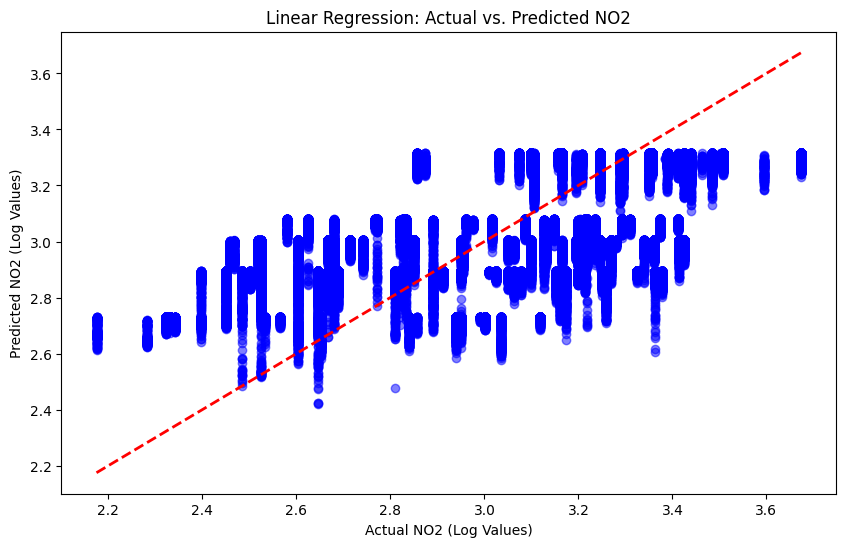

In [60]:
#show linear regression no2 
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_no2, y_pred_no2, alpha=0.5, color='blue')

plt.plot([y_test_no2.min(), y_test_no2.max()], [y_test_no2.min(), y_test_no2.max()], 'r--', lw=2)

plt.xlabel('Actual NO2 (Log Values)')
plt.ylabel('Predicted NO2 (Log Values)')
plt.title('Linear Regression: Actual vs. Predicted NO2')
plt.show()

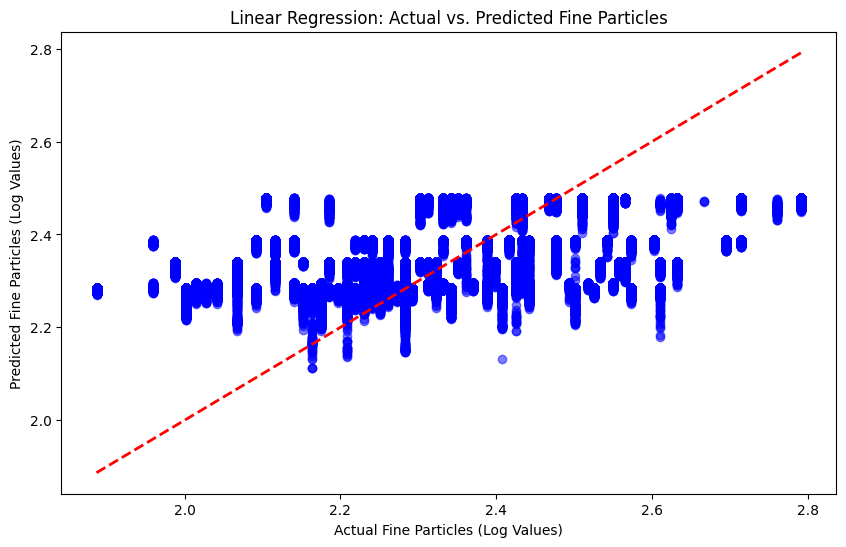

In [61]:

#show linear regression fine particles 
plt.figure(figsize=(10, 6))
plt.scatter(y_test_particles, y_pred_particles, alpha=0.5, color='blue')

plt.plot([y_test_particles.min(), y_test_particles.max()], [y_test_particles.min(), y_test_particles.max()], 'r--', lw=2)

plt.xlabel('Actual Fine Particles (Log Values)')
plt.ylabel('Predicted Fine Particles (Log Values)')
plt.title('Linear Regression: Actual vs. Predicted Fine Particles')
plt.show()

In [62]:
#metrics 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#no2 metrics 
r2_no2 = r2_score(y_test_no2, y_pred_no2)
rmse_no2 = np.sqrt(mean_squared_error(y_test_no2, y_pred_no2))
mae_no2 = mean_absolute_error(y_test_no2, y_pred_no2)
mape_no2 = np.mean(np.abs((y_test_no2 - y_pred_no2) / y_test_no2)) * 100
print("NO2 Linear Regression Model Metrics:")
print(f"R-squared: {r2_no2:.4f}")
print(f"RMSE: {rmse_no2:.4f}")
print(f"MAE (high precision due to log use): {mae_no2:.6f}")
print(f"MAPE(high precision due to log use): {mape_no2:.6f}%")
print(" ")

#fine particles metrics 
r2_particles = r2_score(y_test_particles, y_pred_particles)
rmse_particles = np.sqrt(mean_squared_error(y_test_particles, y_pred_particles))
mae_particles = mean_absolute_error(y_test_particles, y_pred_particles)
mape_particles = np.mean(np.abs((y_test_particles - y_pred_particles) / y_test_particles)) * 100
print("Fine Particles Linear Regression Model Metrics:")
print(f"R-squared: {r2_particles:.4f}")
print(f"RMSE: {rmse_particles:.4f}")
print(f"MAE(high precision due to log use): {mae_particles:.6f}")
print(f"MAPE (high precision due to log use): {mape_particles:.6f}%")

NO2 Linear Regression Model Metrics:
R-squared: 0.2891
RMSE: 0.2616
MAE (high precision due to log use): 0.223823
MAPE(high precision due to log use): 7.676872%
 
Fine Particles Linear Regression Model Metrics:
R-squared: 0.1397
RMSE: 0.1708
MAE(high precision due to log use): 0.141034
MAPE (high precision due to log use): 6.087513%
